In [1]:
import os, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from py_util_dx.py_utils import setProjectPath
from scipy.stats import ttest_ind, ttest_1samp
from evaluations import *
import seaborn as sns 

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
projectPath, mainResultsPath = setProjectPath()
dataset_name = 'MDTB' # or Demand
atlas_name = 'glasser'
# atlas_name = 'yeo17'
# atlas_name = 'schaefer100'
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, 'START_A4_parcellation_evaluation', f'{dataset_name}', atlas_name)

In [4]:
ROIs = ['PFC', 'parietal', 'visual', 'somatosensory'] 
# ROIs = ['PFC'] 
n_rois = len(ROIs) 
# cv_str = '' 
cv_str = '_cv'

## prediction error (cosine distances) computed using cross-validation 
On the training data (for each subject):

$V_{parcels \times conditions} = U_{parcels \times vertices} Y_{vertices \times conditions}$ 

Average V across subjects 

On the test data:

$\hat{Y} = U^{-1} V$ 

Compute the cosine distance between the actual test Y and $\hat{Y}$ 

2-sided independent t-test between group and indiv, PFC, TtestResult(statistic=np.float64(3.469890108659781), pvalue=np.float64(0.0011423493803931518), df=np.float64(46.0))
2-sided independent t-test between group and indiv, parietal, TtestResult(statistic=np.float64(3.7329916946473283), pvalue=np.float64(0.0005195965509866998), df=np.float64(46.0))
2-sided independent t-test between group and indiv, visual, TtestResult(statistic=np.float64(9.768125468208407), pvalue=np.float64(8.537318050552747e-13), df=np.float64(46.0))
2-sided independent t-test between group and indiv, somatosensory, TtestResult(statistic=np.float64(4.519172288864646), pvalue=np.float64(4.324528210291403e-05), df=np.float64(46.0))


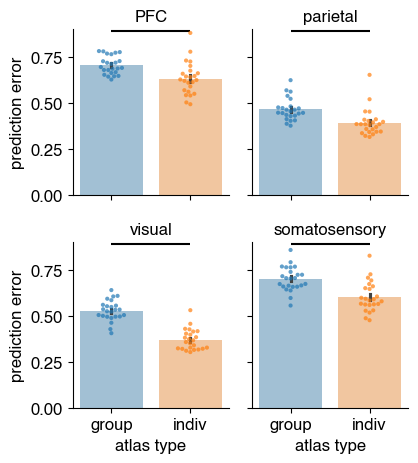

In [5]:
fig, ax = plt.subplots(2, 2, sharex=True, sharey=True)  
fig.set_figwidth(half_width) 

for roiI in np.arange(n_rois):
    PKL_eval_output = os.path.join(resultsPath, f'output_{ROIs[roiI]}{cv_str}.pkl')
    with open(PKL_eval_output, 'rb') as pf:
        output_eval = pickle.load(pf) 
        
    cosine_distances_group = output_eval['cosine_distances_group']
    cosine_distances_indiv = output_eval['cosine_distances_indiv']

    # x_group = np.ones(len(cosine_distances_group))
    # x_indiv = 2*np.ones(len(cosine_distances_indiv))
    # x_cosine_dist = np.concatenate([x_group, x_indiv])
    # cosine_dist_concat = np.concatenate([cosine_distances_group, cosine_distances_indiv])
    ttest_result = ttest_ind(cosine_distances_group, cosine_distances_indiv, alternative='two-sided')            

    # ax.ravel()[roiI].scatter(x_cosine_dist, cosine_dist_concat)
    sns.swarmplot([cosine_distances_group, cosine_distances_indiv], ax=ax.ravel()[roiI], size=3, alpha=0.7)
    sns.barplot([cosine_distances_group, cosine_distances_indiv], errorbar='se', ax=ax.ravel()[roiI], alpha=0.45)
    
    ax.ravel()[roiI].set_xticks([0, 1], labels=['group', 'indiv'], fontsize=12)
    ax.ravel()[roiI].set_xlabel('atlas type', fontsize=12)
    ax.ravel()[roiI].set_ylabel('prediction error', fontsize=12)
    ax.ravel()[roiI].set_ylim([0, 0.9])
    ax.ravel()[roiI].set_title(f'{ROIs[roiI]}', fontsize=12) 
    ax.ravel()[roiI].spines['top'].set_visible(False)
    ax.ravel()[roiI].spines['right'].set_visible(False)

    significance_level = 0.05 
    if ttest_result.pvalue < significance_level:
        ax.ravel()[roiI].hlines(0.89, xmin=0, xmax=1, color='k')

    print(f'2-sided independent t-test between group and indiv, {ROIs[roiI]}, {ttest_result}')

# plt.suptitle('prediction error') 
plt.tight_layout() 

JPG_fig = os.path.join(resultsPath, f'prediction_error.jpg')
plt.savefig(JPG_fig, dpi=500, format='jpg')

## within- and between-parcel correlations

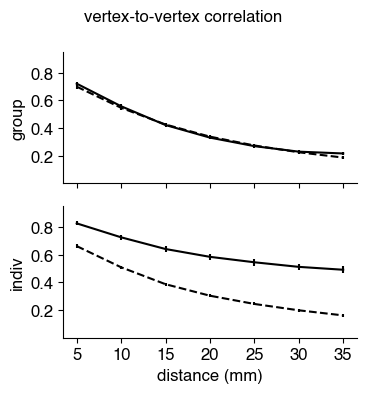

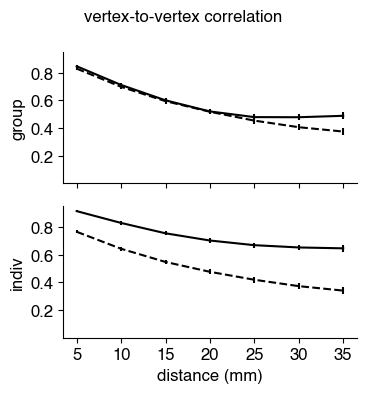

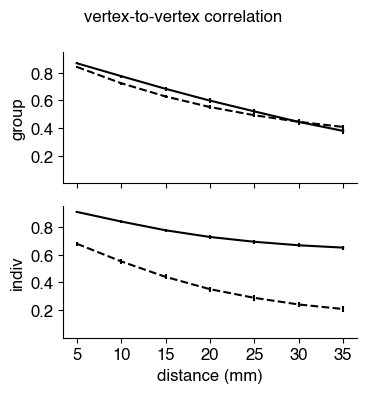

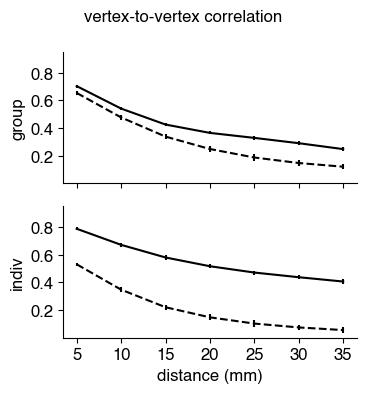

In [6]:
# fig, ax = plt.subplots(n_rois, 2, figsize=(half_width, 12))

# fig.set_figheight(8) 

for roiI in np.arange(n_rois):
    fig, ax = plt.subplots(2, 1, sharex=True) 
    fig.set_figwidth(0.9*half_width) 
    fig.set_figheight(4) 
    
    PKL_eval_output = os.path.join(resultsPath, f'output_{ROIs[roiI]}{cv_str}.pkl')
    with open(PKL_eval_output, 'rb') as pf:
        output_eval = pickle.load(pf) 
    output_dcbc_group = output_eval['output_dcbc_group']
    output_dcbc_indiv = output_eval['output_dcbc_indiv']

    # group 
    within_corrs = output_dcbc_group['within_corrs'] 
    between_corrs = output_dcbc_group['between_corrs']

    n_subjects = within_corrs.shape[0]

    within_corrs_mean = np.mean(within_corrs, axis=0)
    within_corrs_ste = np.std(within_corrs, axis=0) / np.sqrt(n_subjects)
    between_corrs_mean = np.mean(between_corrs, axis=0)
    between_corrs_ste = np.std(between_corrs, axis=0) / np.sqrt(n_subjects)

    distances = 5+np.arange(0, 35, step=5) 
    ax[0].errorbar(distances, within_corrs_mean, yerr=within_corrs_ste, color='k')
    ax[0].errorbar(distances, between_corrs_mean, yerr=between_corrs_ste, color='k', linestyle='--')
    # ax[0].set_xlabel('distance (mm)', fontsize=12)
    # ax[0].set_ylabel('vertex-to-vertex\n correlations', fontsize=12)
    ax[0].set_ylabel('group', fontsize=12)
    ax[0].set_ylim([0, 0.95])
    ax[0].set_yticks(np.arange(0.2, 0.95, 0.2))
    ax[0].set_yticklabels(ax[0].get_yticklabels(), fontsize=12)
    # ax[0].set_xticks(distances, labels=distances) 
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    plt.legend(['within', 'between'], frameon=False, fontsize=12)
    # ax[roiI, 0].set_title(f'group {ROIs[roiI]}') 

    # indiv
    within_corrs = output_dcbc_indiv['within_corrs'] 
    between_corrs = output_dcbc_indiv['between_corrs']

    within_corrs_mean = np.mean(within_corrs, axis=0)
    within_corrs_ste = np.std(within_corrs, axis=0) / np.sqrt(n_subjects)
    between_corrs_mean = np.mean(between_corrs, axis=0)
    between_corrs_ste = np.std(between_corrs, axis=0) / np.sqrt(n_subjects)

    ax[1].errorbar(distances, within_corrs_mean, yerr=within_corrs_ste, color='k')
    ax[1].errorbar(distances, between_corrs_mean, yerr=between_corrs_ste, color='k', linestyle='--')
    ax[1].set_xlabel('distance (mm)', fontsize=12)
    # ax[1].set_ylabel('vertex-to-vertex\n correlations', fontsize=12)
    ax[1].set_ylabel('indiv', fontsize=12)
    ax[1].set_ylim([0, 0.95])
    ax[1].set_yticks(np.arange(0.2, 0.95, 0.2))
    ax[1].set_xticks(distances, labels=distances) 
    ax[1].set_yticklabels(ax[1].get_yticklabels(), fontsize=12)
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)
    # plt.legend(['within', 'between'], frameon=False, fontsize=12)
    # ax[roiI, 1].set_title(f'indiv {ROIs[roiI]}') 

    plt.suptitle('vertex-to-vertex correlation', fontsize=12) 
    plt.tight_layout() 

    JPG_fig = os.path.join(resultsPath, f'dcbc_corr_curves{cv_str}_{ROIs[roiI]}.jpg')
    plt.savefig(JPG_fig, dpi=500, format='jpg')

In [7]:
n_subjects 

24

In [8]:
# # fig, ax = plt.subplots(n_rois, 2, figsize=(half_width, 12))
# fig, ax = plt.subplots(1, 2, sharey=True) 
# fig.set_figwidth(half_width) 
# # fig.set_figheight(8) 

# for roiI in np.arange(n_rois):
#     PKL_eval_output = os.path.join(resultsPath, f'output_{ROIs[roiI]}{cv_str}.pkl')
#     with open(PKL_eval_output, 'rb') as pf:
#         output_eval = pickle.load(pf) 
#     output_dcbc_group = output_eval['output_dcbc_group']
#     output_dcbc_indiv = output_eval['output_dcbc_indiv']

#     # group 
#     within_corrs = output_dcbc_group['within_corrs'] 
#     between_corrs = output_dcbc_group['between_corrs']

#     n_subjects = within_corrs.shape[0]

#     within_corrs_mean = np.mean(within_corrs, axis=0)
#     within_corrs_ste = np.std(within_corrs, axis=0) / np.sqrt(n_subjects)
#     between_corrs_mean = np.mean(between_corrs, axis=0)
#     between_corrs_ste = np.std(between_corrs, axis=0) / np.sqrt(n_subjects)

#     distances = 5+np.arange(0, 35, step=5) 
#     ax[roiI, 0].errorbar(distances, within_corrs_mean, yerr=within_corrs_ste, color='k')
#     ax[roiI, 0].errorbar(distances, between_corrs_mean, yerr=between_corrs_ste, color='k', linestyle='--')
#     ax[roiI, 0].set_xlabel('distance (mm)', fontsize=12)
#     ax[roiI, 0].set_ylabel('vertex-to-vertex correlations', fontsize=12)
#     ax[roiI, 0].set_ylim([0, 1])
#     ax[roiI, 0].set_xticks(distances, labels=distances) 
#     ax[roiI, 0].spines['top'].set_visible(False)
#     ax[roiI, 0].spines['right'].set_visible(False)
#     plt.legend(['within', 'between'], frameon=False, fontsize=12)
#     # ax[roiI, 0].set_title(f'group {ROIs[roiI]}') 

#     # indiv
#     within_corrs = output_dcbc_indiv['within_corrs'] 
#     between_corrs = output_dcbc_indiv['between_corrs']

#     within_corrs_mean = np.mean(within_corrs, axis=0)
#     within_corrs_ste = np.std(within_corrs, axis=0) / np.sqrt(n_subjects)
#     between_corrs_mean = np.mean(between_corrs, axis=0)
#     between_corrs_ste = np.std(between_corrs, axis=0) / np.sqrt(n_subjects)

#     ax[roiI, 1].errorbar(distances, within_corrs_mean, yerr=within_corrs_ste, color='k')
#     ax[roiI, 1].errorbar(distances, between_corrs_mean, yerr=between_corrs_ste, color='k', linestyle='--')
#     ax[roiI, 1].set_xlabel('distance (mm)', fontsize=12)
#     ax[roiI, 1].set_ylabel('vertex-to-vertex correlations', fontsize=12)
#     ax[roiI, 1].set_ylim([0, 1])
#     ax[roiI, 1].set_xticks(distances, labels=distances) 
#     ax[roiI, 1].spines['top'].set_visible(False)
#     ax[roiI, 1].spines['right'].set_visible(False)
#     plt.legend(['within', 'between'], frameon=False, fontsize=12)
#     # ax[roiI, 1].set_title(f'indiv {ROIs[roiI]}') 

# plt.suptitle('vertex-to-vertex correlation') 
# plt.tight_layout() 

# JPG_fig = os.path.join(resultsPath, f'dcbc_corr_curves{cv_str}.jpg')
# plt.savefig(JPG_fig, dpi=500, format='jpg')

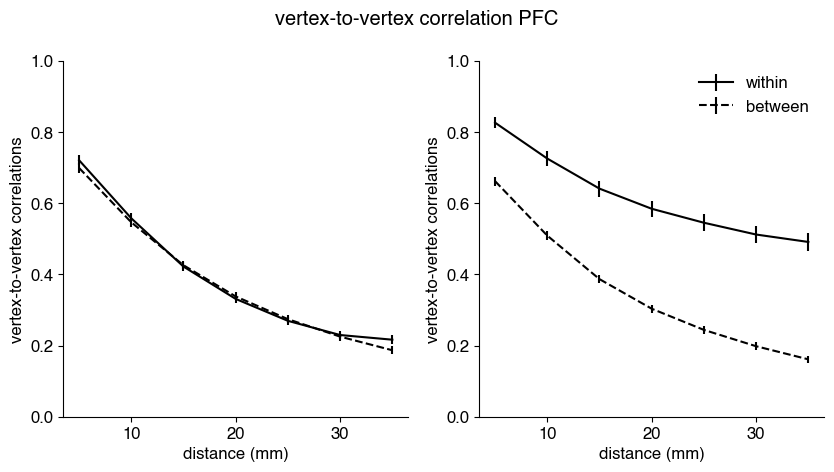

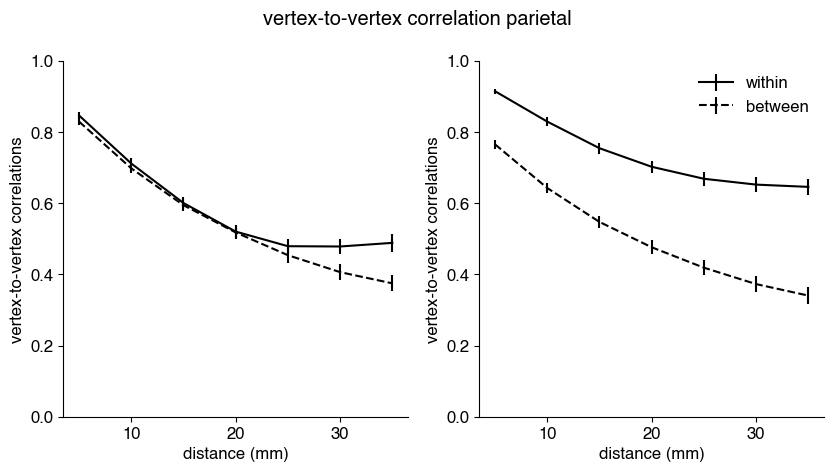

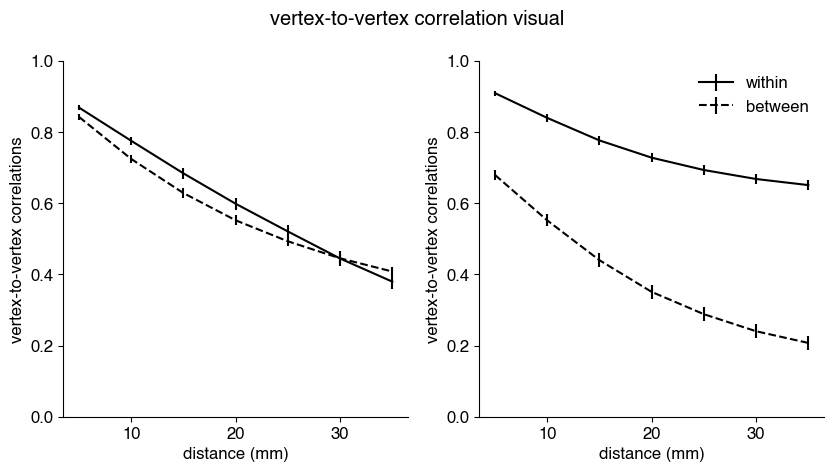

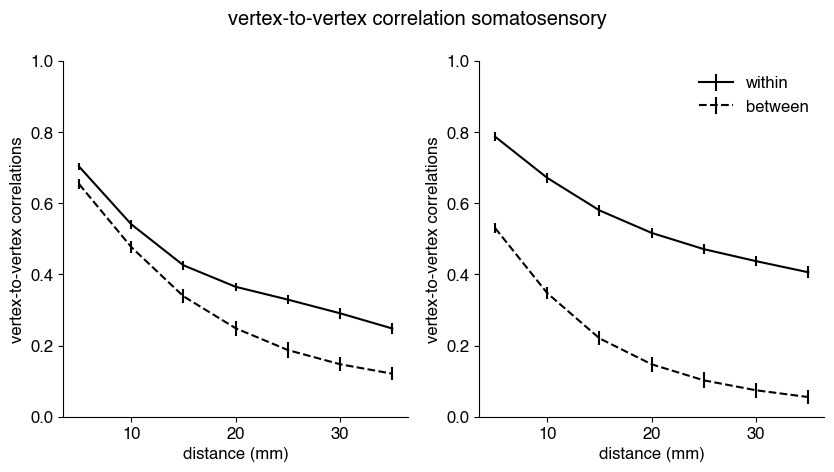

In [9]:
for roiI in np.arange(n_rois):    
    PKL_eval_output = os.path.join(resultsPath, f'output_{ROIs[roiI]}{cv_str}.pkl')
    with open(PKL_eval_output, 'rb') as pf:
        output_eval = pickle.load(pf) 
    output_dcbc_group = output_eval['output_dcbc_group']
    output_dcbc_indiv = output_eval['output_dcbc_indiv']

    # group 
    within_corrs = output_dcbc_group['within_corrs'] 
    between_corrs = output_dcbc_group['between_corrs']

    n_subjects = within_corrs.shape[0]

    within_corrs_mean = np.mean(within_corrs, axis=0)
    within_corrs_ste = np.std(within_corrs, axis=0) / np.sqrt(n_subjects)
    between_corrs_mean = np.mean(between_corrs, axis=0)
    between_corrs_ste = np.std(between_corrs, axis=0) / np.sqrt(n_subjects)

    fig, ax = plt.subplots(1, 2)
    fig.set_figwidth(full_width)

    ax[0].errorbar(5+np.arange(0, 35, step=5), within_corrs_mean, yerr=within_corrs_ste, color='k')
    ax[0].errorbar(5+np.arange(0, 35, step=5), between_corrs_mean, yerr=between_corrs_ste, color='k', linestyle='--')
    ax[0].set_xlabel('distance (mm)', fontsize=12)
    ax[0].set_ylabel('vertex-to-vertex correlations', fontsize=12)
    ax[0].set_ylim([0, 1])
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    plt.legend(['within', 'between'], frameon=False, fontsize=12)
    # ax[roiI, 0].set_title(f'group {ROIs[roiI]}') 

    # indiv
    within_corrs = output_dcbc_indiv['within_corrs'] 
    between_corrs = output_dcbc_indiv['between_corrs']

    within_corrs_mean = np.mean(within_corrs, axis=0)
    within_corrs_ste = np.std(within_corrs, axis=0) / np.sqrt(n_subjects)
    between_corrs_mean = np.mean(between_corrs, axis=0)
    between_corrs_ste = np.std(between_corrs, axis=0) / np.sqrt(n_subjects)

    ax[1].errorbar(5+np.arange(0, 35, step=5), within_corrs_mean, yerr=within_corrs_ste, color='k')
    ax[1].errorbar(5+np.arange(0, 35, step=5), between_corrs_mean, yerr=between_corrs_ste, color='k', linestyle='--')
    ax[1].set_xlabel('distance (mm)', fontsize=12)
    ax[1].set_ylabel('vertex-to-vertex correlations')
    ax[1].set_ylim([0, 1])
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)
    plt.legend(['within', 'between'], frameon=False, fontsize=12)
    # ax[roiI, 1].set_title(f'indiv {ROIs[roiI]}') 

    plt.suptitle(f'vertex-to-vertex correlation {ROIs[roiI]}') 
    plt.tight_layout() 

    JPG_fig = os.path.join(resultsPath, f'dcbc_corr_curves_{ROIs[roiI]}{cv_str}.jpg')
    plt.savefig(JPG_fig, dpi=500, format='jpg')

## DCBC for group and individualized atlases 

t-test between group and indiv, PFC, p-val=1.6632700376731505e-18, t=-14.265583185250723, df=46.0
t-test against 0, group PFC, p-val=0.44397962343279374, t=0.1424574956766359, df=23
t-test against 0, indiv PFC, p-val=1.6758428172753356e-13, t=14.728624284357114, df=23
t-test between group and indiv, parietal, p-val=6.414966859804625e-17, t=-12.924553155980684, df=46.0
t-test against 0, group parietal, p-val=0.012715245571715982, t=2.390000923881068, df=23
t-test against 0, indiv parietal, p-val=7.255770053401391e-15, t=17.086255235660964, df=23
t-test between group and indiv, visual, p-val=1.3202502731820822e-21, t=-17.143579763599774, df=46.0
t-test against 0, group visual, p-val=0.08315626799930678, t=1.4294695777427446, df=23
t-test against 0, indiv visual, p-val=3.734261016075289e-17, t=21.7814511000484, df=23
t-test between group and indiv, somatosensory, p-val=1.144852204374427e-09, t=-7.602995364764424, df=46.0
t-test against 0, group somatosensory, p-val=2.330422828600047e-06, 

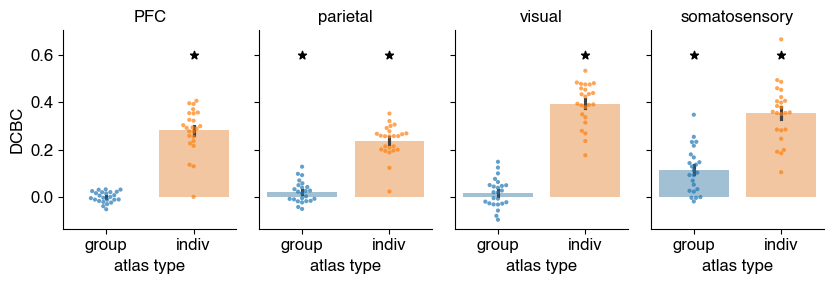

In [10]:
# fig, axs = plt.subplots(2, 2, sharey=True, sharex=True) 
# fig.set_figwidth(half_width)

fig, axs = plt.subplots(1, n_rois, sharey=True) 
fig.set_figwidth(full_width)
fig.set_figheight(3)

for roiI in np.arange(n_rois):
    PKL_eval_output = os.path.join(resultsPath, f'output_{ROIs[roiI]}{cv_str}.pkl')
    with open(PKL_eval_output, 'rb') as pf:
        output_eval = pickle.load(pf) 
    output_dcbc_group = output_eval['output_dcbc_group']
    output_dcbc_indiv = output_eval['output_dcbc_indiv']

    dcbc_group = output_dcbc_group['dcbc']
    dcbc_indiv = output_dcbc_indiv['dcbc']
    
    sns.swarmplot([dcbc_group, dcbc_indiv], ax=axs.ravel()[roiI], size=3, alpha=0.7) 
    sns.barplot([dcbc_group, dcbc_indiv], errorbar='se', ax=axs.ravel()[roiI], alpha=0.45) 
    
    axs.ravel()[roiI].set_xticks([0, 1], labels=['group', 'indiv'], fontsize=12)
    axs.ravel()[roiI].set_xlabel('atlas type', fontsize=12)
    # axs.ravel()[roiI].set_ylabel('DCBC', fontsize=12) 
    axs.ravel()[roiI].set_title(f'{ROIs[roiI]}', fontsize=12) 
    axs.ravel()[roiI].spines['top'].set_visible(False)
    axs.ravel()[roiI].spines['right'].set_visible(False)
    
    ## some statistical tests
    significance_level = 0.05 

    ## t-test comparing group and individual 
    ttest_gi = ttest_ind(dcbc_group, dcbc_indiv, alternative='two-sided') 
    # if ttest_gi.pvalue < significance_level:
    #     axs.ravel()[roiI].hlines(0.5, xmin=1, xmax=2, linestyles='-', colors=(150/255, 150/255, 150/255)) 
    print(f't-test between group and indiv, {ROIs[roiI]}, p-val={ttest_gi.pvalue}, t={ttest_gi.statistic}, df={ttest_gi.df}')

    ## testing dcbc against 0 
    # group 
    ttest_0_g = ttest_1samp(dcbc_group, 0, alternative='greater')
    if ttest_0_g.pvalue < significance_level:
        axs.ravel()[roiI].scatter(0, 0.6, c='k', marker='*') 
    print(f't-test against 0, group {ROIs[roiI]}, p-val={ttest_0_g.pvalue}, t={ttest_0_g.statistic}, df={ttest_0_g.df}')
    # indiv
    ttest_0_i = ttest_1samp(dcbc_indiv, 0, alternative='greater')
    if ttest_0_i.pvalue < significance_level:
        axs.ravel()[roiI].scatter(1, 0.6, c='k', marker='*')
    print(f't-test against 0, indiv {ROIs[roiI]}, p-val={ttest_0_i.pvalue}, t={ttest_0_i.statistic}, df={ttest_0_i.df}')

axs.ravel()[0].set_ylabel('DCBC', fontsize=12) 
plt.tight_layout() 

JPG_fig = os.path.join(resultsPath, f'dcbc_group_indiv{cv_str}.jpg')
plt.savefig(JPG_fig, format='jpg', dpi=500) 

## spatial ACF 

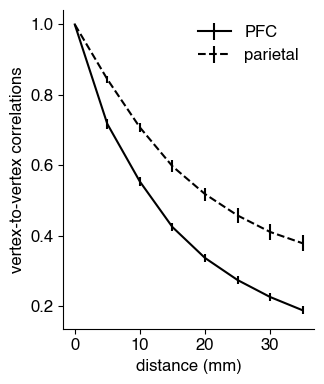

In [11]:
ROIs = ['PFC', 'parietal'] 
corrs = [] 
linestyles = ['-', '--']

fig, ax = plt.subplots(1, 1)
fig.set_figwidth(half_width*0.8) 
fig.set_figheight(4) 

for roiI in np.arange(len(ROIs)):
    PKL_output = os.path.join(mainResultsPath, 'START_A7_spatialACF', dataset_name, f'output_{ROIs[roiI]}_cv.pkl')
    with open(PKL_output, 'rb') as pf:
        output = pickle.load(pf) 

    corrs_this_roi = output['corrs'] 
    distances = output['distances'] 
    corrs.append(corrs_this_roi) 
    
    corrs_mean = np.mean(corrs_this_roi, axis=0) 
    corrs_ste = np.std(corrs_this_roi, axis=0) / np.sqrt(corrs_this_roi.shape[0]) 

    ax.errorbar(distances, corrs_mean, corrs_ste, label=ROIs[roiI], linestyle=linestyles[roiI], color='k')  
    ax.set_xlabel('distance (mm)', fontsize=12) 
    ax.set_ylabel('vertex-to-vertex correlations', fontsize=12) 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.legend(frameon=False, fontsize=12)  
plt.tight_layout() 

JPG_fig = os.path.join(resultsPath, f'spatial_ACF_{atlas_name}.jpg')
plt.savefig(JPG_fig, dpi=500, format='jpg') 